In [1]:
import os
import time

import numpy as np
import torch

import evaluation
from dataset import TKGDataset
from training import Trainer, OracleTrainer, Logger
import matplotlib

import torch.nn as nn
import torch.nn.functional as F

from utils import *

In [2]:
# Model configuration
MODEL_CONFIG = {
    'embedding_dim': 200,
    'dropout': 0.5,
    'alpha': 0.2,
    'lambdax': 10,
    'oracle_mode': 'soft',
    'filtering': True,
}

# Training configuration
TRAINING_CONFIG = {
    'batch_size': 1024,
    'max_epochs': 30,
    'oracle_epochs': 20,
    'valid_epochs': 5,
    'lr': 0.001,
    'oracle_lr': 0.001,
    'weight_decay': 1.0e-05,
    'use_seed': True,
    'seed': 987,
}

# System configuration
SYSTEM_CONFIG = {
    'gpu_id': '0',
    'use_cuda': True,
    'only_oracle': False,
    'only_eva': False,
    'save_dir': 'SAVE',
    'model_dir': '',
}

# Dataset-specific configurations (overrides defaults)
DATASET_CONFIGS = {
    'YAGO': {
        'dataset': 'YAGO',
        'description': 'yago_hard',
        'model': {
            'alpha': 0.2,
            'lambdax': 2,
            'oracle_mode': 'hard',
        }
    },
    'GDELT': {
        'dataset': 'GDELT',
        'description': 'gdelt_default',
    },
    'ICEWS14': {
        'dataset': 'ICEWS14',
        'description': 'icews14_default',
    },
    'ICEWS18': {
        'dataset': 'ICEWS18',
        'description': 'icews18_default',
    },
    'WIKI': {
        'dataset': 'WIKI',
        'description': 'wiki_default',
    },
}

In [3]:
class Oracle(nn.Module):
    def __init__(self, input_dim, out_dim):
        super(Oracle, self).__init__()
        self.linear = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2),
            nn.Linear(input_dim, out_dim)
        )

    def forward(self, x):
        return self.linear(x)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from utils import *
import copy

class Oracle(nn.Module):
    def __init__(self, input_dim, out_dim):
        super(Oracle, self).__init__()
        self.linear = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2),
            nn.Linear(input_dim, out_dim)
        )

    def forward(self, x):
        return self.linear(x)


class CENET(nn.Module):
    def __init__(self, num_e, num_rel, num_t, embedding_dim, dropout, lambdax, alpha, oracle_mode, filtering):
        super(CENET, self).__init__()
        # stats
        self.num_e = num_e
        self.num_t = num_t
        self.num_rel = num_rel
        self.embedding_dim = embedding_dim
        self.lambdax = lambdax
        self.alpha = alpha
        self.oracle_mode = oracle_mode
        self.filtering = filtering

        # entity relation embedding
        self.rel_embeds = nn.Parameter(torch.zeros(2 * num_rel, embedding_dim))
        self.entity_embeds = nn.Parameter(torch.zeros(self.num_e, embedding_dim))

        self.linear_frequency = nn.Linear(self.num_e, embedding_dim)

        self.contrastive_hidden_layer = nn.Linear(3 * embedding_dim, embedding_dim)
        self.oracle_layer = Oracle(3 * embedding_dim, 1)

        self.linear_pred_layer_s1 = nn.Linear(2 * embedding_dim, embedding_dim)
        self.linear_pred_layer_o1 = nn.Linear(2 * embedding_dim, embedding_dim)

        self.linear_pred_layer_s2 = nn.Linear(2 * embedding_dim, embedding_dim)
        self.linear_pred_layer_o2 = nn.Linear(2 * embedding_dim, embedding_dim)

        # Initialize weights and embeddings
        self.reset_parameters()

        self.dropout = nn.Dropout(dropout)
        self.tanh = nn.Tanh()
        self.crossEntropy = nn.BCELoss()

    def reset_parameters(self):
        """Initialize all parameters and embeddings using Xavier uniform distribution."""
        gain = nn.init.calculate_gain('relu')
        
        # Initialize embeddings
        nn.init.xavier_uniform_(self.rel_embeds, gain=gain)
        nn.init.xavier_uniform_(self.entity_embeds, gain=gain)
        
        # Initialize layers
        self.weights_init(self.linear_frequency)
        self.weights_init(self.linear_pred_layer_s1)
        self.weights_init(self.linear_pred_layer_o1)
        self.weights_init(self.linear_pred_layer_s2)
        self.weights_init(self.linear_pred_layer_o2)
        self.oracle_layer.apply(self.weights_init)

    @staticmethod
    def weights_init(m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('relu'))
            
    def history_and_non_history_depedency(self, s_frequency, o_frequency, lambdax):
        s_history_tag = copy.deepcopy(s_frequency)
        o_history_tag = copy.deepcopy(o_frequency)
        s_non_history_tag = copy.deepcopy(s_frequency)
        o_non_history_tag = copy.deepcopy(o_frequency)

        s_history_tag[s_history_tag != 0] = lambdax
        o_history_tag[o_history_tag != 0] = lambdax

        s_non_history_tag[s_history_tag == 1] = -lambdax
        s_non_history_tag[s_history_tag == 0] = lambdax

        o_non_history_tag[o_history_tag == 1] = -lambdax
        o_non_history_tag[o_history_tag == 0] = lambdax

        s_history_tag[s_history_tag == 0] = -lambdax
        o_history_tag[o_history_tag == 0] = -lambdax

        return s_history_tag, o_history_tag, s_non_history_tag, o_non_history_tag

    def forward(self, batch_block, mode_lk, total_data=None):
        quadruples, s_history_event_o, o_history_event_s, \
        s_history_label_true, o_history_label_true, s_frequency, o_frequency = batch_block

        if isListEmpty(s_history_event_o) or isListEmpty(o_history_event_s):
            return (None, None) if mode_lk in ['Valid', 'Test'] else None

        s, r, o = quadruples[:, :3].T
        s_history_tag, o_history_tag,\
            s_non_history_tag, o_non_history_tag = self.history_and_non_history_depedency(s_frequency, o_frequency, self.lambdax)

        s_frequency = F.softmax(s_frequency, dim=1)
        o_frequency = F.softmax(o_frequency, dim=1)
        s_frequency_hidden = self.tanh(self.linear_frequency(s_frequency))
        o_frequency_hidden = self.tanh(self.linear_frequency(o_frequency))

        if mode_lk == 'Training':
            s_nce_loss, _ = self.calculate_nce_loss(s, o, r, self.rel_embeds[:self.num_rel],
                                                    self.linear_pred_layer_s1, self.linear_pred_layer_s2,
                                                    s_history_tag, s_non_history_tag)
            o_nce_loss, _ = self.calculate_nce_loss(o, s, r, self.rel_embeds[self.num_rel:],
                                                    self.linear_pred_layer_o1, self.linear_pred_layer_o2,
                                                    o_history_tag, o_non_history_tag)
            # calculate_spc_loss(self, hidden_lk, actor1, r, rel_embeds, targets):
            s_spc_loss = self.calculate_spc_loss(s, r, self.rel_embeds[:self.num_rel],
                                                 s_history_label_true, s_frequency_hidden)
            o_spc_loss = self.calculate_spc_loss(o, r, self.rel_embeds[self.num_rel:],
                                                 o_history_label_true, o_frequency_hidden)
            nce_loss = (s_nce_loss + o_nce_loss) / 2.0
            spc_loss = (s_spc_loss + o_spc_loss) / 2.0
            # print('nce loss', nce_loss.item(), ' spc loss', spc_loss.item())
            return self.alpha * nce_loss + (1 - self.alpha) * spc_loss

        elif mode_lk in ['Valid', 'Test']:
            s_history_oid = []
            o_history_sid = []

            for i in range(quadruples.shape[0]):
                s_history_oid.append([])
                o_history_sid.append([])
                for con_events in s_history_event_o[i]:
                    s_history_oid[-1] += con_events[:, 1].tolist()
                for con_events in o_history_event_s[i]:
                    o_history_sid[-1] += con_events[:, 1].tolist()

            s_nce_loss, s_preds = self.calculate_nce_loss(s, o, r, self.rel_embeds[:self.num_rel],
                                                          self.linear_pred_layer_s1, self.linear_pred_layer_s2,
                                                          s_history_tag, s_non_history_tag)
            o_nce_loss, o_preds = self.calculate_nce_loss(o, s, r, self.rel_embeds[self.num_rel:],
                                                          self.linear_pred_layer_o1, self.linear_pred_layer_o2,
                                                          o_history_tag, o_non_history_tag)

            s_ce_loss, s_pred_history_label, s_ce_all_acc = self.oracle_loss(s, r, self.rel_embeds[:self.num_rel],
                                                                             s_history_label_true, s_frequency_hidden)
            o_ce_loss, o_pred_history_label, o_ce_all_acc = self.oracle_loss(o, r, self.rel_embeds[self.num_rel:],
                                                                             o_history_label_true, o_frequency_hidden)

            s_mask = torch.zeros(quadruples.shape[0], self.num_e, device=quadruples.device)
            o_mask = torch.zeros(quadruples.shape[0], self.num_e, device=quadruples.device)

            for i in range(quadruples.shape[0]):
                if s_pred_history_label[i].item() > 0.5:
                    s_mask[i, s_history_oid[i]] = 1
                else:
                    s_mask[i, :] = 1
                    s_mask[i, s_history_oid[i]] = 0

                if o_pred_history_label[i].item() > 0.5:
                    o_mask[i, o_history_sid[i]] = 1
                else:
                    o_mask[i, :] = 1
                    o_mask[i, o_history_sid[i]] = 0

            if self.oracle_mode == 'soft':
                s_mask = F.softmax(s_mask, dim=1)
                o_mask = F.softmax(o_mask, dim=1)


            s_total_loss1, sub_rank1 = self.link_predict(s_nce_loss, s_preds, s_ce_loss, s, o, r,
                                                         s_mask, total_data, 's', True)
            o_total_loss1, obj_rank1 = self.link_predict(o_nce_loss, o_preds, o_ce_loss, o, s, r,
                                                         o_mask, total_data, 'o', True)
            batch_loss1 = (s_total_loss1 + o_total_loss1) / 2.0

            s_total_loss2, sub_rank2 = self.link_predict(s_nce_loss, s_preds, s_ce_loss, s, o, r,
                                                         s_mask, total_data, 's', False)
            o_total_loss2, obj_rank2 = self.link_predict(o_nce_loss, o_preds, o_ce_loss, o, s, r,
                                                         o_mask, total_data, 'o', False)
            batch_loss2 = (s_total_loss2 + o_total_loss2) / 2.0

            # Ground Truth
            s_mask_gt = torch.zeros(quadruples.shape[0], self.num_e, device=quadruples.device)
            o_mask_gt = torch.zeros(quadruples.shape[0], self.num_e, device=quadruples.device)


            for i in range(quadruples.shape[0]):
                if o[i] in s_history_oid[i]:
                    s_mask_gt[i, s_history_oid[i]] = 1
                else:
                    s_mask_gt[i, :] = 1
                    s_mask_gt[i, s_history_oid[i]] = 0

                if s[i] in o_history_sid[i]:
                    o_mask_gt[i, o_history_sid[i]] = 1
                else:
                    o_mask_gt[i, :] = 1
                    o_mask_gt[i, o_history_sid[i]] = 0

            s_total_loss3, sub_rank3 = self.link_predict(s_nce_loss, s_preds, s_ce_loss, s, o, r,
                                                         s_mask_gt, total_data, 's', True)
            o_total_loss3, obj_rank3 = self.link_predict(o_nce_loss, o_preds, o_ce_loss, o, s, r,
                                                         o_mask_gt, total_data, 'o', True)
            batch_loss3 = (s_total_loss3 + o_total_loss3) / 2.0

            return sub_rank1, obj_rank1, batch_loss1, \
                   sub_rank2, obj_rank2, batch_loss2, \
                   sub_rank3, obj_rank3, batch_loss3, \
                   (s_ce_all_acc + o_ce_all_acc) / 2

        elif mode_lk == 'Oracle':
            # print('Oracle Training')
            s_ce_loss, _, _ = self.oracle_loss(s, r, self.rel_embeds[:self.num_rel],
                                               s_history_label_true, s_frequency_hidden)
            o_ce_loss, _, _ = self.oracle_loss(o, r, self.rel_embeds[self.num_rel:],
                                               o_history_label_true, o_frequency_hidden)
            return (s_ce_loss + o_ce_loss) / 2.0 + self.oracle_l1(0.01)

    def oracle_loss(self, actor1, r, rel_embeds, history_label, frequency_hidden):
        history_label_pred = F.sigmoid(
            self.oracle_layer(torch.cat((self.entity_embeds[actor1], rel_embeds[r], frequency_hidden), dim=1)))
        tmp_label = torch.squeeze(history_label_pred).clone().detach()
        tmp_label[torch.where(tmp_label > 0.5)[0]] = 1
        tmp_label[torch.where(tmp_label < 0.5)[0]] = 0
        # print('# Bias Ratio', torch.sum(tmp_label).item() / tmp_label.shape[0])
        ce_correct = torch.sum(torch.eq(tmp_label, torch.squeeze(history_label)))
        ce_accuracy = 1. * ce_correct.item() / tmp_label.shape[0]
        # print('# CE Accuracy', ce_accuracy)
        ce_loss = self.crossEntropy(torch.squeeze(history_label_pred), torch.squeeze(history_label))
        return ce_loss, history_label_pred, ce_accuracy * tmp_label.shape[0]

    def calculate_nce_loss(self, actor1, actor2, r, rel_embeds, linear1, linear2, history_tag, non_history_tag):
        preds_raw1 = self.tanh(linear1(
            self.dropout(torch.cat((self.entity_embeds[actor1], rel_embeds[r]), dim=1))))
        preds1 = F.softmax(preds_raw1.mm(self.entity_embeds.transpose(0, 1)) + history_tag, dim=1)

        preds_raw2 = self.tanh(linear2(
            self.dropout(torch.cat((self.entity_embeds[actor1], rel_embeds[r]), dim=1))))
        preds2 = F.softmax(preds_raw2.mm(self.entity_embeds.transpose(0, 1)) + non_history_tag, dim=1)

        # cro_entr_loss = self.criterion_link(preds1 + preds2, actor2)

        nce = torch.sum(torch.gather(torch.log(preds1 + preds2), 1, actor2.view(-1, 1)))
        nce /= -1. * actor2.shape[0]

        pred_actor2 = torch.argmax(preds1 + preds2, dim=1)  # predicted result
        correct = torch.sum(torch.eq(pred_actor2, actor2))
        accuracy = 1. * correct.item() / actor2.shape[0]
        # print('# Batch accuracy', accuracy)

        return nce, preds1 + preds2

    def link_predict(self, nce_loss, preds, ce_loss, actor1, actor2, r, trust_musk, all_triples, pred_known, oracle):
        if oracle:
            preds = torch.mul(preds, trust_musk)

        # compute the correct triples
        pred_actor2 = torch.argmax(preds, dim=1)  # predicted result
        correct = torch.sum(torch.eq(pred_actor2, actor2))
        accuracy = 1. * correct.item() / actor2.shape[0]
        # print(accuracy)
        # print('Batch Error', 1 - accuracy)

        total_loss = nce_loss + ce_loss

        ranks = []
        for i in range(preds.shape[0]):
            cur_s = actor1[i]
            cur_r = r[i]
            cur_o = actor2[i]

            o_label = cur_o
            ground = preds[i, cur_o].clone().item()
            if self.filtering:
                if pred_known == 's':
                    s_id = torch.nonzero(all_triples[:, 0] == cur_s).view(-1)
                    idx = torch.nonzero(all_triples[s_id, 1] == cur_r).view(-1)
                    idx = s_id[idx]
                    idx = all_triples[idx, 2]
                else:
                    s_id = torch.nonzero(all_triples[:, 2] == cur_s).view(-1)
                    idx = torch.nonzero(all_triples[s_id, 1] == cur_r).view(-1)
                    idx = s_id[idx]
                    idx = all_triples[idx, 0]

                preds[i, idx] = 0
                preds[i, o_label] = ground

            ob_pred_comp1 = (preds[i, :] > ground).data.cpu().numpy()
            ob_pred_comp2 = (preds[i, :] == ground).data.cpu().numpy()
            ranks.append(np.sum(ob_pred_comp1) + ((np.sum(ob_pred_comp2) - 1.0) / 2) + 1)
        return total_loss, ranks

    def oracle_l1(self, reg_param):
        reg = 0
        for param in self.oracle_layer.parameters():
            reg += torch.sum(torch.abs(param))
        return reg * reg_param

    # contrastive
    def freeze_parameter(self):
        self.rel_embeds.requires_grad_(False)
        self.entity_embeds.requires_grad_(False)
        self.linear_pred_layer_s1.requires_grad_(False)
        self.linear_pred_layer_o1.requires_grad_(False)
        self.linear_pred_layer_s2.requires_grad_(False)
        self.linear_pred_layer_o2.requires_grad_(False)
        self.linear_frequency.requires_grad_(False)
        self.contrastive_hidden_layer.requires_grad_(False)

    def contrastive_layer(self, x):
        x = self.contrastive_hidden_layer(x)
        return x

    def calculate_spc_loss(self, actor1, r, rel_embeds, targets, frequency_hidden):
        projections = self.contrastive_layer(
            torch.cat((self.entity_embeds[actor1], rel_embeds[r], frequency_hidden), dim=1))
        targets = torch.squeeze(targets)
        dot_product_tempered = torch.mm(projections, projections.T) / 1.0
        # Minus max for numerical stability with exponential. Same done in cross entropy. Epsilon added to avoid log(0)
        exp_dot_tempered = torch.exp(dot_product_tempered - torch.max(dot_product_tempered, dim=1, keepdim=True)[0]) + 1e-5
        mask_similar_class = (targets.unsqueeze(1).repeat(1, targets.shape[0]) == targets).to(projections.device)
        mask_anchor_out = (1 - torch.eye(exp_dot_tempered.shape[0])).to(projections.device)
        mask_combined = mask_similar_class * mask_anchor_out
        cardinality_per_samples = torch.sum(mask_combined, dim=1)
        log_prob = -torch.log(exp_dot_tempered / (torch.sum(exp_dot_tempered * mask_anchor_out, dim=1, keepdim=True)))
        supervised_contrastive_loss_per_sample = torch.sum(log_prob * mask_combined, dim=1) / cardinality_per_samples

        supervised_contrastive_loss = torch.mean(supervised_contrastive_loss_per_sample)
        if torch.any(torch.isnan(supervised_contrastive_loss)):
            return 0
        return supervised_contrastive_loss

In [5]:
dataset_name = 'YAGO'  # Change to: 'GDELT', 'ICEWS14', 'ICEWS18', 'WIKI'

# Get configs from dictionaries by passing them as parameters
model_config, training_config, system_config = get_configs(
    dataset_name, 
    MODEL_CONFIG, 
    TRAINING_CONFIG, 
    SYSTEM_CONFIG, 
    DATASET_CONFIGS
)

# Setup GPU/CPU
use_cuda = system_config['use_cuda'] and torch.cuda.is_available()
system_config['use_cuda'] = use_cuda
device = torch.device(f'cuda:{system_config["gpu_id"]}' if use_cuda else 'cpu')

# Setup seed if enabled
if training_config['use_seed']:
    seed = training_config['seed']
    np.random.seed(seed)
    torch.manual_seed(seed)
    print(f"Seed set to: {seed}")

# Setup directories
os.makedirs(system_config['save_dir'], exist_ok=True)

print(f"Dataset: {system_config['dataset']}")
print(f"Device: {device}")
print(f"CUDA available: {use_cuda}")

Seed set to: 987
Dataset: YAGO
Device: cuda:0
CUDA available: True


In [6]:
dataset = TKGDataset(system_config['dataset'])
num_nodes = dataset.num_nodes
num_rels = dataset.num_rels
num_t = dataset.num_t

print(f"Nodes: {num_nodes}, Relations: {num_rels}, Timestamps: {num_t}")

Nodes: 10623, Relations: 10, Timestamps: 189


In [7]:
trainer = None
test_logger = None

if not system_config['only_eva'] and not system_config['only_oracle']:
    # Create model
    model = CENET(
        num_nodes,
        num_rels,
        num_t,
        embedding_dim=model_config['embedding_dim'],
        dropout=model_config['dropout'],
        lambdax=model_config['lambdax'],
        alpha=model_config['alpha'],
        oracle_mode=model_config['oracle_mode'],
        filtering=model_config['filtering'],
    )
    
    # Setup optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=training_config['lr'],
        weight_decay=training_config['weight_decay']
    )
    model = model.to(device)
    
    # Create trainer
    trainer = Trainer(
        model, optimizer, training_config, dataset,
        num_rels, num_nodes, num_t,
        save_dir=system_config['save_dir'],
        dataset_name=system_config['dataset'],
        use_cuda=use_cuda,
        device=device
    )
    trainer.log_config(model_config, training_config, system_config)
    trainer.log_model_info()
    model_path = trainer.train()
    main_dirName = os.path.dirname(model_path)
    test_logger = trainer.get_logger()
else:
    # Load existing model
    main_dirName = os.path.join(system_config['save_dir'], system_config['model_dir'])
    model_path = os.path.join(main_dirName, 'models')
    logger_instance = Logger(system_config['save_dir'], system_config['dataset'])
    test_logger = logger_instance
    main_dirName = logger_instance.get_log_dir()

print(f"Model path: {model_path}")

Model Configuration:
  alpha                = 0.2
  dropout              = 0.5
  embedding_dim        = 200
  filtering            = True
  lambdax              = 2
  oracle_mode          = hard
Training Configuration:
  batch_size           = 1024
  lr                   = 0.001
  max_epochs           = 30
  oracle_epochs        = 20
  oracle_lr            = 0.001
  seed                 = 987
  use_seed             = True
  valid_epochs         = 5
  weight_decay         = 1e-05
System Configuration:
  dataset              = YAGO
  gpu_id               = 0
  model_dir            = 
  only_eva             = False
  only_oracle          = False
  save_dir             = SAVE
  use_cuda             = True

Model Information:
  Total Parameters: 5,056,801
  Trainable Parameters: 5,056,801
  GPU Memory Reserved:  0.02 GB
  GPU Memory Allocated: 0.02 GB
  GPU Memory Peak:      0.02 GB
Epoch 1/30


Training Epoch 1: 100%|██████████| 158/158 [00:05<00:00, 30.93batch/s, loss=5.8425, avg_loss=5.9239]


[TRAIN] Epoch 1: Loss = 5.923944 (Time: 5.11s)
[VRAM] Peak: 0.15GB | Reserved: 0.22GB
Epoch 2/30


Training Epoch 2: 100%|██████████| 158/158 [00:04<00:00, 33.04batch/s, loss=5.7785, avg_loss=5.8129]


[TRAIN] Epoch 2: Loss = 5.812930 (Time: 4.79s)
[VRAM] Peak: 0.15GB | Reserved: 0.22GB
Epoch 3/30


...

[TRAIN] Epoch 29: Loss = 5.587081 (Time: 4.81s)
[VRAM] Peak: 0.15GB | Reserved: 0.22GB
Epoch 30/30


Training Epoch 30: 100%|██████████| 158/158 [00:05<00:00, 31.43batch/s, loss=5.5377, avg_loss=5.5863]


[TRAIN] Epoch 30: Loss = 5.586285 (Time: 5.03s)
[VRAM] Peak: 0.15GB | Reserved: 0.22GB
[VALIDATION] Epoch 30


Validating: 100%|██████████| 20/20 [01:29<00:00,  4.50s/batch]

  [No Oracle Filtering]
    Subject test MRR (lk): 0.835102
    Subject test MR (lk): 141.399017
    Subject test Hits (lk) @ 1: 0.820007
    Subject test Hits (lk) @ 3: 0.840752
    Subject test Hits (lk) @ 10: 0.862777
    Object test MRR (lk): 0.830291
    Object test MR (lk): 162.421400
    Object test Hits (lk) @ 1: 0.820366
    Object test Hits (lk) @ 3: 0.832864
    Object test Hits (lk) @ 10: 0.847257
    ALL test MRR (lk): 0.832696
    ALL test MR (lk): 151.910208
    ALL test Hits (lk) @ 1: 0.820186
    ALL test Hits (lk) @ 3: 0.836808
    ALL test Hits (lk) @ 10: 0.855017
  [Ground Truth Oracle]
    Subject test MRR (lk): 0.893510
    Subject test MR (lk): 133.308201
    Subject test Hits (lk) @ 1: 0.887415
    Subject test Hits (lk) @ 3: 0.895201
    Subject test Hits (lk) @ 10: 0.902986
    Object test MRR (lk): 0.889172
    Object test MR (lk): 152.904984
    Object test Hits (lk) @ 1: 0.886698
    Object test Hits (lk) @ 3: 0.888593
    Object test Hits (lk) @ 10: 0.8927

In [8]:
# Create a fresh model instance for oracle training
model = CENET(
    num_nodes,
    num_rels,
    num_t,
    embedding_dim=model_config['embedding_dim'],
    dropout=model_config['dropout'],
    lambdax=model_config['lambdax'],
    alpha=model_config['alpha'],
    oracle_mode=model_config['oracle_mode'],
    filtering=model_config['filtering'],
)
model = model.to(device)

# Load the saved weights
pth_path = os.path.join(model_path, f'{system_config["dataset"]}_best.pth')

try:
    # Thử load state_dict trước (an toàn, weights_only=True)
    checkpoint = torch.load(pth_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
except Exception:
    # Legacy: file lưu toàn bộ model object
    checkpoint = torch.load(pth_path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        model = checkpoint.to(device)

# Ensure model is on the correct device
model = model.to(device)

oracle_trainer = OracleTrainer(
    model, training_config, dataset, model_path,
    dataset_name=system_config['dataset'],
    use_cuda=use_cuda,
    device=device,
    logger=test_logger
)
oracle_trainer.train()

# Save model state_dict (lightweight format)
torch.save(model.state_dict(), os.path.join(model_path, f'{system_config["dataset"]}_best.pth'))
print("Oracle training complete. Model weights saved.")

[ORACLE TRAINING PHASE]
Starting Oracle training...


Oracle Epoch 1:   9%|▉         | 15/158 [00:00<00:03, 41.55batch/s, loss=138.0529, avg_loss=161.9128]

Oracle Epoch 1: 100%|██████████| 158/158 [00:03<00:00, 41.23batch/s, loss=6.4168, avg_loss=46.5483]  


[ORACLE] Epoch 1: Loss = 46.548337 (Time: 3.83s)


Oracle Epoch 2: 100%|██████████| 158/158 [00:03<00:00, 41.24batch/s, loss=5.0594, avg_loss=5.6186]


...

[ORACLE] Epoch 18: Loss = 0.694690 (Time: 3.72s)


Oracle Epoch 19: 100%|██████████| 158/158 [00:03<00:00, 42.66batch/s, loss=0.8380, avg_loss=0.6954]


[ORACLE] Epoch 19: Loss = 0.695425 (Time: 3.70s)


Oracle Epoch 20: 100%|██████████| 158/158 [00:03<00:00, 42.64batch/s, loss=0.8356, avg_loss=0.6949]


[ORACLE] Epoch 20: Loss = 0.694919 (Time: 3.71s)
Oracle training completed!
Oracle training complete. Model weights saved.


In [9]:
if system_config['only_eva']:
    main_dirName = os.path.join(system_config['save_dir'], system_config['model_dir'])
    model_path = os.path.join(main_dirName, 'models')

test_logger.write("[TEST PHASE]")
test_logger.write("Testing starts...")

time_begin = time.time()

# Khởi tạo model với cấu trúc đúng
model = CENET(
    num_nodes,
    num_rels,
    num_t,
    embedding_dim=model_config['embedding_dim'],
    dropout=model_config['dropout'],
    lambdax=model_config['lambdax'],
    alpha=model_config['alpha'],
    oracle_mode=model_config['oracle_mode'],
    filtering=model_config['filtering'],
)

# Load weights — hỗ trợ cả state_dict (format mới) lẫn full model object (legacy)
pth_path = os.path.join(model_path, f'{system_config["dataset"]}_best.pth')

try:
    # Thử load state_dict trước (an toàn, weights_only=True)
    checkpoint = torch.load(pth_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
except Exception:
    # Legacy: file lưu toàn bộ model object
    checkpoint = torch.load(pth_path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        model = checkpoint

# Move model to device và set eval mode
model = model.to(device)
model.eval()

# Convert total_data một lần, truyền tensor vào execute_test
total_data_tensor = torch.from_numpy(dataset.total_data).to(device)

s_ranks1, o_ranks1, all_ranks1, \
_, _, _, \
_, _, _, \
avg_loss = evaluation.execute_test(
    training_config['batch_size'],
    total_data_tensor,
    model,
    dataset.test_data,
    dataset.test_s_history, dataset.test_o_history,
    dataset.test_s_label, dataset.test_o_label,
    dataset.test_s_frequency, dataset.test_o_frequency
)

test_time = time.time() - time_begin
test_logger.write("Test Results (Oracle):")
write2file_to_logger(s_ranks1, o_ranks1, all_ranks1, test_logger)
test_logger.write(f"Avg Loss: {avg_loss:.6f}")
test_logger.write(f"Testing completed! (Time: {test_time:.2f}s)")
test_logger.close()

print(f"Evaluation done in {test_time:.2f}s")

[TEST PHASE]
Testing starts...


Testing:   0%|          | 0/20 [00:00<?, ?batch/s]

Testing: 100%|██████████| 20/20 [01:35<00:00,  4.77s/batch]

Test Results (Oracle):
    Subject test MRR (lk): 0.842822
    Subject test MR (lk): 738.509338
    Subject test Hits (lk) @ 1: 0.839609
    Subject test Hits (lk) @ 3: 0.845051
    Subject test Hits (lk) @ 10: 0.847249
    Object test MRR (lk): 0.841718
    Object test MR (lk): 772.921951
    Object test Hits (lk) @ 1: 0.841356
    Object test Hits (lk) @ 3: 0.841856
    Object test Hits (lk) @ 10: 0.842355
    ALL test MRR (lk): 0.842270
    ALL test MR (lk): 755.715645
    ALL test Hits (lk) @ 1: 0.840482
    ALL test Hits (lk) @ 3: 0.843454
    ALL test Hits (lk) @ 10: 0.844802
Avg Loss: 2.939188
Testing completed! (Time: 95.51s)
Evaluation done in 95.51s


In [10]:

# ==================== Save Current Config to YAML ====================
import yaml
import pandas as pd
import os

config_dst_dir = os.path.join(main_dirName, 'configs')
os.makedirs(config_dst_dir, exist_ok=True)

# Combine all configs into one dictionary
combined_config = {
    'model': model_config,
    'training': training_config,
    'system': system_config
}

# Save combined config to single YAML file
config_file = os.path.join(config_dst_dir, 'config.yaml')
with open(config_file, 'w') as f:
    yaml.dump(combined_config, f, default_flow_style=False)
print(f"Combined config saved to: {config_file}")

Combined config saved to: SAVE/version_2_YAGO/configs/config.yaml


Loss plot saved to: SAVE/version_2_YAGO/loss_plot.png


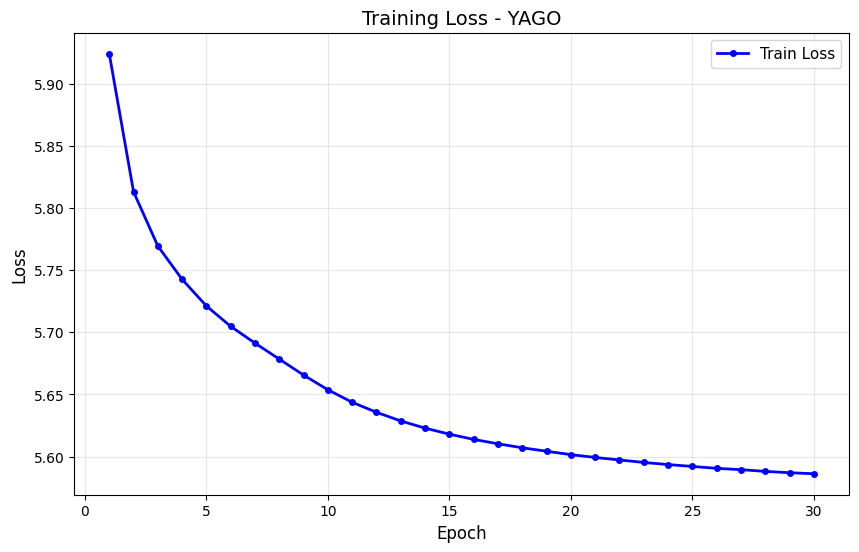

In [11]:
import matplotlib.pyplot as plt

metrics_file = os.path.join(main_dirName, 'metrics.csv')

if os.path.exists(metrics_file):
    # Read metrics from CSV
    df = pd.read_csv(metrics_file)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot training loss
    ax.plot(df['Epoch'], df['Train Loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Training Loss - {system_config["dataset"]}', fontsize=14)
    
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Save plot
    plot_file = os.path.join(main_dirName, 'loss_plot.png')
    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    print(f"Loss plot saved to: {plot_file}")
    
    # Display plot
    plt.show()
else:
    print(f"Metrics file not found: {metrics_file}")

Loss plot saved to: SAVE/version_2_YAGO/val_loss_plot.png


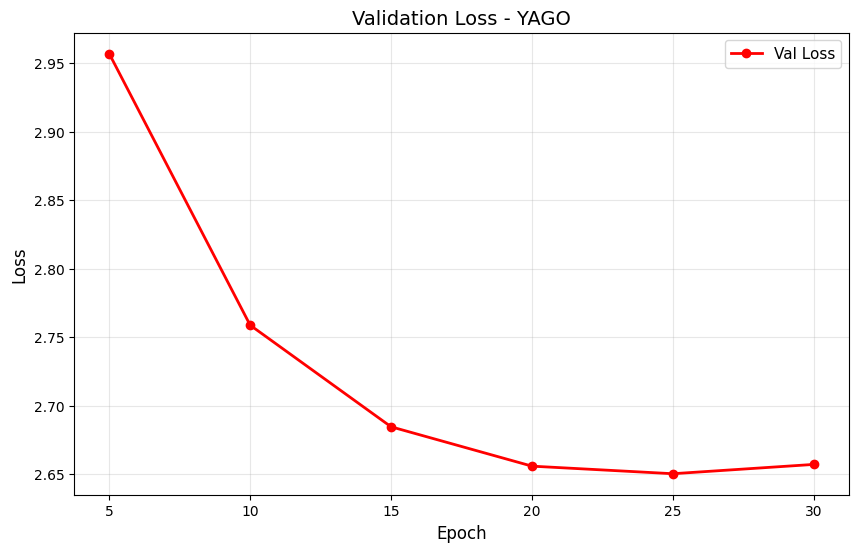

In [12]:
import matplotlib.pyplot as plt

metrics_file = os.path.join(main_dirName, 'metrics.csv')

if os.path.exists(metrics_file):
    # Read metrics from CSV
    df = pd.read_csv(metrics_file)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Filter out NaN values for Val Loss
    valid_data = df.dropna(subset=['Val Loss'])
    
    # Plot validation loss (only non-NaN points)
    ax.plot(valid_data['Epoch'], valid_data['Val Loss'], 'r-o', label='Val Loss', linewidth=2, markersize=6)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Validation Loss - {system_config["dataset"]}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Save plot
    plot_file = os.path.join(main_dirName, 'val_loss_plot.png')

    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    print(f"Loss plot saved to: {plot_file}")
    
    # Display plot
    plt.show()
else:
    print(f"Metrics file not found: {metrics_file}")